# T_1 Experiment

This notebook demonstrates how to perform a measurement of the lifetime of a qubit, assuming qubit rotations are already calibrated.

## 0. General Imports and Definitions

### 0.1 Python Imports 

In [1]:
# Helpers:
from laboneq.contrib.example_helpers.generate_device_setup import (
    generate_device_setup_qubits,
)
from laboneq.contrib.example_helpers.plotting.plot_helpers import *

# LabOne Q:
from laboneq.simple import *

## 1. Device Setup

Below, you'll create a device setup and choose to run this notebook in emulated mode or directly on the control hardware, by specifying `use_emulation = True/False` respectively.

If you run on your hardware, you need to generate a device setup first, please have a look at our [device setup tutorial](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/00_device_setup/tutorials/00_device_setup.html) for how to do this in general.
Here, we use a helper functions to generate the device setup and a set up qubit objects with pre-defined parameters. 

In [2]:
# specify the number of qubits you want to use
number_of_qubits = 2

# generate the device setup and the qubit objects using a helper function
device_setup, qubits = generate_device_setup_qubits(
    number_qubits=number_of_qubits,
    pqsc=[{"serial": "DEV10001"}],
    hdawg=[
        {
            "serial": "DEV8001",
            "number_of_channels": 8,
            "options": None,
        }
    ],
    shfqc=[
        {
            "serial": "DEV12001",
            "number_of_channels": 6,
            "readout_multiplex": 6,
            "options": None,
        }
    ],
    multiplex_drive_lines=True,
    include_flux_lines=True,
    server_host="localhost",
    setup_name=f"my_{number_of_qubits}_tunable_qubit_setup",
)

q0, q1 = qubits[:2]

In [3]:
# use emulation mode - no connection to instruments
use_emulation = True

# create and connect to a session
session = Session(device_setup=device_setup)
session.connect(do_emulation=use_emulation)

[2026.06.30 16:38:49.803] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/khatran/Desktop/pico-thermometry/pulse-sequences/laboneq_output/log
[2026.06.30 16:38:49.805] INFO    VERSION: laboneq 26.4.0
[2026.06.30 16:38:49.805] INFO    Connecting to data server at localhost:8004
[2026.06.30 16:38:49.807] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at localhost:8004
[2026.06.30 16:38:49.808] INFO    Configuring the device setup
[2026.06.30 16:38:49.834] INFO    The device setup is configured


## 2. Experiment Definition

In [4]:
#  signal map for qubit


def map_qubit(qubit):
    return {
        "drive": qubit.signals["drive"],
        "measure": qubit.signals["measure"],
        "acquire": qubit.signals["acquire"],
    }

In [5]:
## define pulses
# qubit drive pulse - use amplitude calibrated by amplitude Rabi experiment
x180 = pulse_library.gaussian(uid="x180", length=100e-9, amplitude=0.66)
# readout drive pulse
readout_pulse = pulse_library.const(uid="readout_pulse", length=400e-9, amplitude=1.0)
# readout integration weights
readout_weighting_function = pulse_library.const(
    uid="readout_weighting_function", length=400e-9, amplitude=1.0
)

### 2.1 Experiment Pulse Sequence

In [6]:
# sweep parameter - delay before readout / after pi pulse
count = 11
start = 0
stop = 1e-6
delay_sweep = LinearSweepParameter(uid="delay", start=start, stop=stop, count=count)

# number of averages
average_exponent = 4  # used for 2^n averages, n=average_exponent, maximum: n = 17

# Create Experiment
exp = Experiment(
    uid="T1 experiment",
    signals=[
        ExperimentSignal("drive"),
        ExperimentSignal("measure"),
        ExperimentSignal("acquire"),
    ],
)
## experimental pulse sequence
# outer loop - real-time, cyclic averaging in standard integration mode
with exp.acquire_loop_rt(
    uid="shots",
    count=pow(2, average_exponent),
    averaging_mode=AveragingMode.CYCLIC,
    acquisition_type=AcquisitionType.INTEGRATION,
    repetition_mode=RepetitionMode.AUTO,  # compiler sets repetition time to shortest possible constant time
):
    # inner loop - sweep over delay between qubit excitation and readout pulse
    # right alignment makes sure the readout section follows a fixed timing, being the last element in each shot
    with exp.sweep(
        uid="sweep", parameter=delay_sweep, alignment=SectionAlignment.RIGHT
    ):
        # qubit drive pulse followed by variable delay
        with exp.section(uid="qubit_excitation", alignment=SectionAlignment.RIGHT):
            exp.play(signal="drive", pulse=x180)
            exp.delay(signal="drive", time=delay_sweep)
        # qubit readout pulse and data acquisition
        with exp.section(uid="qubit_readout", play_after="qubit_excitation"):
            # play readout pulse
            exp.play(signal="measure", pulse=readout_pulse)
            # signal data acquisition
            exp.acquire(
                signal="acquire",
                handle="ac_0",
                kernel=readout_weighting_function,
            )
        # relax time after readout - for signal processing and qubit relaxation to ground state
        with exp.section(uid="relax", length=1e-6):
            exp.reserve(signal="measure")

In [7]:
# define signal maps for qubit 0
map_q0 = {
    "drive": device_setup.logical_signal_groups["q0"].logical_signals["drive"],
    "measure": device_setup.logical_signal_groups["q0"].logical_signals["measure"],
    "acquire": device_setup.logical_signal_groups["q0"].logical_signals["acquire"],
}

### 2.2 Run the Experiment and Plot the Measurement Results and Pulse Sheet

In [8]:
# map exp to qubit 0
exp.set_signal_map(map_qubit(q0))

# run on qubit 0
my_results = session.run(exp)

[2026.06.30 16:38:49.862] INFO    Starting LabOne Q Compiler run...
[2026.06.30 16:38:49.867] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Software
[2026.06.30 16:38:49.868] INFO    Resolved modulation type of oscillator on signal: 'drive' to Hardware
[2026.06.30 16:38:49.868] INFO    Resolved modulation type of oscillator on signal: 'measure' to Software
[2026.06.30 16:38:49.869] INFO    Schedule completed. [0.001 s]
[2026.06.30 16:38:49.876] INFO    Code generation completed for all AWGs. [0.007 s]
[2026.06.30 16:38:49.876] INFO    Completed compilation step 1 of 1. [0.008 s]
[2026.06.30 16:38:49.880] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.30 16:38:49.880] INFO      Device       AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.30 16:38:49.880] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.30 16:38:49.880] INFO      shfqc_0        0         10            0          

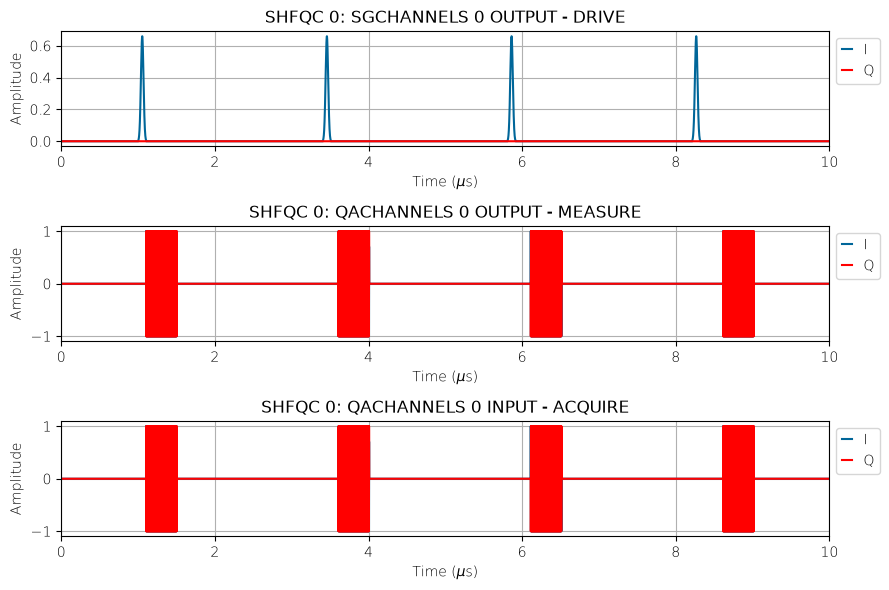

In [9]:
# Plot simulated output signals
plot_simulation(session.compiled_experiment, start_time=0, length=10e-6)

In [10]:
# plot measurement results
plot_result_2d(my_results, "ac_0")

In [11]:
# use pulse sheet viewer to display the pulse sequence - only recommended for small number of averages and sweep steps to avoid performance issues
show_pulse_sheet("T1", session.compiled_experiment)

[2026.06.30 16:38:50.265] INFO    Recompiling the experiment due to missing extra information in the compiled experiment. Compile with `OUTPUT_EXTRAS=True` and `MAX_EVENTS_TO_PUBLISH=1000` to bypass this step with a small impact on the compilation time.
[2026.06.30 16:38:50.268] INFO    Starting LabOne Q Compiler run...
[2026.06.30 16:38:50.269] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Software
[2026.06.30 16:38:50.269] INFO    Resolved modulation type of oscillator on signal: 'drive' to Hardware
[2026.06.30 16:38:50.269] INFO    Resolved modulation type of oscillator on signal: 'measure' to Software
[2026.06.30 16:38:50.272] INFO    Schedule completed. [0.003 s]
[2026.06.30 16:38:50.274] INFO    Code generation completed for all AWGs. [0.001 s]
[2026.06.30 16:38:50.274] INFO    Completed compilation step 1 of 1. [0.005 s]
[2026.06.30 16:38:50.276] INFO    Finished LabOne Q Compiler run.
[2026.06.30 16:38:50.277] WARNING Pulse sheet viewer: The event list 

/Users/khatran/Desktop/pico-thermometry/pulse-sequences/T1_2026-06-30-16-38-50.html

In [12]:
# map exp to qubit 1
exp.set_signal_map(map_qubit(q1))

# run on qubit 1
my_results = session.run(exp)

[2026.06.30 16:38:50.287] INFO    Starting LabOne Q Compiler run...
[2026.06.30 16:38:50.288] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Software
[2026.06.30 16:38:50.288] INFO    Resolved modulation type of oscillator on signal: 'drive' to Hardware
[2026.06.30 16:38:50.288] INFO    Resolved modulation type of oscillator on signal: 'measure' to Software
[2026.06.30 16:38:50.289] INFO    Schedule completed. [0.000 s]
[2026.06.30 16:38:50.290] INFO    Code generation completed for all AWGs. [0.001 s]
[2026.06.30 16:38:50.291] INFO    Completed compilation step 1 of 1. [0.002 s]
[2026.06.30 16:38:50.292] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.30 16:38:50.292] INFO      Device       AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.30 16:38:50.292] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.30 16:38:50.292] INFO      shfqc_0        0         10            0          